# Team 1 Data Science Project On "E-commerce Website Traffic Analysis".

## Problem Statement : Analyze website traffic data to identify peak visit times, user behavior, and conversion trends.

### Installing and Importing Libraries "Pandas & Numpy".

In [4]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np

### Importing Dataset file

In [11]:
df = pd.read_excel("Ecommerce_Website_Traffic_India_more_data.xlsx")

### To check first five dataset in file give this command.

In [14]:
df.head()



,date,time,user_id,traffic_source,device,city,state,session_duration_sec,pages_viewed,bounce,...,office_equipments,beauty_products,clothing,technical_devices,add_to_cart,purchase,order_value,age,gender,festival
0,2024-11-08 00:00:00,19:23:09,U100000,Organic Search,Tablet,Ranchi,Jharkhand,2152,16,0,...,0,48,25,51,1,0,0.0,41,Male,Diwali
1,2024-05-25 00:00:00,15:47:18,U100001,Referral,Mobile,Bhubaneswar,Odisha,3161,16,0,...,0,31,46,62,0,0,0.0,34,Female,Holi
2,2024-05-02 00:00:00,NaN,U100002,Organic Search,Tablet,Chennai,Tamil Nadu,2151,3,0,...,18,10,1,0,0,0,0.0,46,Female,Pongal
3,2024-10-09 00:00:00,12:39:18,U100003,Direct,Mobile,Kolkata,West Bengal,2941,2,0,...,0,7,1,0,0,0,0.0,32,Male,Pongal
4,2024-01-17 00:00:00,10:57:32,NaN,Paid Ads,Tablet,Trivandrum,Kerala,2648,1,1,...,0,46,78,56,0,0,0.0,18,Female,Navratri


In [16]:
df.tail()

,date,time,user_id,traffic_source,device,city,state,session_duration_sec,pages_viewed,bounce,...,office_equipments,beauty_products,clothing,technical_devices,add_to_cart,purchase,order_value,age,gender,festival
14999,2024-08-29 00:00:00,14:15:03,U114999,Email,Tablet,Agartala,Tripura,2150,5,0,...,0,13,31,38,0,0,0.0,33,Female,Holi
15000,2024-11-08 00:00:00,19:23:09,U100000,Organic Search,Tablet,Ranchi,Jharkhand,2152,16,0,...,0,48,25,51,1,0,0.0,41,Male,Diwali
15001,2024-05-25 00:00:00,15:47:18,U100001,Referral,Mobile,Bhubaneswar,Odisha,3161,16,0,...,0,31,46,62,0,0,0.0,34,Female,Holi
15002,2024-11-08 00:00:00,19:23:09,U100000,Organic Search,Tablet,Ranchi,Jharkhand,2152,16,0,...,0,48,25,51,1,0,0.0,41,Male,Diwali
15003,2024-10-09 00:00:00,12:39:18,U100003,Direct,Mobile,Kolkata,West Bengal,2941,2,0,...,0,7,1,0,0,0,0.0,32,Male,Pongal


### Standardize column Names

In [19]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns


Index(['date', 'time', 'user_id', 'traffic_source', 'device', 'city', 'state',
       'session_duration_sec', 'pages_viewed', 'bounce', 'product_viewed',
       'home_appliances', 'office_equipments', 'beauty_products', 'clothing',
       'technical_devices', 'add_to_cart', 'purchase', 'order_value', 'age',
       'gender', 'festival'],
      dtype='object')

## Data Cleaning Process of Dataset.

### Checking and Removing Duplicate Rows

#### To Check Duplicate Data give this command


In [24]:
df.duplicated().sum()

3

#### To Remove Duplicate Data give this command

In [27]:
df = df.drop_duplicates()

df.duplicated().sum()

0

### Handling Missing Values (NULLs)

#### To Check Missing Values Use This Command

In [31]:
df.isnull().sum()

date                    0
time                    1
user_id                 1
traffic_source          0
device                  0
city                    0
state                   0
session_duration_sec    0
pages_viewed            0
bounce                  0
product_viewed          0
home_appliances         0
office_equipments       0
beauty_products         0
clothing                0
technical_devices       0
add_to_cart             0
purchase                0
order_value             0
age                     0
gender                  0
festival                0
dtype: int64

#### To Handle Missing Values Use This Command

##### Dropping the row where user_id is missing

In [35]:
df = df.dropna(subset=['user_id'])

##### Dropping the row where time is missing

In [38]:
df = df.dropna(subset=['time'])

#### Verifying Missing Values Are handled Or Not.

In [41]:
df.isnull().sum()

date                    0
time                    0
user_id                 0
traffic_source          0
device                  0
city                    0
state                   0
session_duration_sec    0
pages_viewed            0
bounce                  0
product_viewed          0
home_appliances         0
office_equipments       0
beauty_products         0
clothing                0
technical_devices       0
add_to_cart             0
purchase                0
order_value             0
age                     0
gender                  0
festival                0
dtype: int64

#### To Fill missing NUMERIC values with mean

In [44]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].mean()
)

#### To Fill missing CATEGORICAL values with mode

In [47]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


### To Fix Incorrect & Inconsistent Data

#### To Remove Case inconsistency (Delhi → delhi)

In [51]:
for col in categorical_cols:
    df[col] = df[col].str.lower()

#### To Remove Trailing / Extra Spaces

In [54]:
for col in categorical_cols:
    df[col] = df[col].str.strip()


#### To Fix invalid numeric values (negative numbers)

In [57]:
for col in numeric_cols:
    df[col] = df[col].apply(lambda x: x if x >= 0 else np.nan)

# Refill after fixing
df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].mean()
)


#### To Handle Outliers (IQR Method)

In [60]:
def iqr_clean(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]
    


In [62]:
for col in numeric_cols:
    df = iqr_clean(df, col)


#### To Check Correct Data Types

In [65]:
df.dtypes

date                     object
time                     object
user_id                  object
traffic_source           object
device                   object
city                     object
state                    object
session_duration_sec      int64
pages_viewed              int64
bounce                    int64
product_viewed            int64
home_appliances           int64
office_equipments         int64
beauty_products           int64
clothing                  int64
technical_devices         int64
add_to_cart               int64
purchase                  int64
order_value             float64
age                       int64
gender                   object
festival                 object
dtype: object

In [67]:
# Example corrections
if 'page_views' in df.columns:
    df['page_views'] = df['page_views'].astype(int)

if 'revenue' in df.columns:
    df['revenue'] = df['revenue'].astype(float)

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])


### To Validate Data

#### For Range Validation

In [71]:
# Example: session duration must be positive
if 'session_duration' in df.columns:
    df = df[df['session_duration'] > 0]


#### For Value Validation

In [74]:
# Example: valid device types
if 'device_type' in df.columns:
    valid_devices = ['mobile', 'desktop', 'tablet']
    df = df[df['device_type'].isin(valid_devices)]


### Final Clean Dataset Check

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9883 entries, 0 to 15001
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  1 non-null      datetime64[ns]
 1   time                  9883 non-null   object        
 2   user_id               9883 non-null   object        
 3   traffic_source        9883 non-null   object        
 4   device                9883 non-null   object        
 5   city                  9883 non-null   object        
 6   state                 9883 non-null   object        
 7   session_duration_sec  9883 non-null   int64         
 8   pages_viewed          9883 non-null   int64         
 9   bounce                9883 non-null   int64         
 10  product_viewed        9883 non-null   int64         
 11  home_appliances       9883 non-null   int64         
 12  office_equipments     9883 non-null   int64         
 13  beauty_products       

In [79]:
df.describe()


,date,session_duration_sec,pages_viewed,bounce,product_viewed,home_appliances,office_equipments,beauty_products,clothing,technical_devices,add_to_cart,purchase,order_value,age
count,1,9883.000000,9883.000000,9883.000000,9883.000000,9883.0,9883.0,9883.000000,9883.000000,9883.000000,9883.000000,9883.0,9883.0,9883.000000
mean,2024-05-25 00:00:00,2265.599616,13.009916,0.280482,0.419812,0.0,0.0,23.342305,33.469493,24.923303,0.169382,0.0,0.0,30.114338
min,2024-05-25 00:00:00,20.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,10.000000
25%,2024-05-25 00:00:00,1136.500000,7.000000,0.000000,0.000000,0.0,0.0,9.000000,12.000000,0.000000,0.000000,0.0,0.0,20.000000
50%,2024-05-25 00:00:00,2255.000000,13.000000,0.000000,0.000000,0.0,0.0,17.000000,30.000000,23.000000,0.000000,0.0,0.0,30.000000
75%,2024-05-25 00:00:00,3415.500000,19.000000,1.000000,1.000000,0.0,0.0,38.000000,55.000000,46.000000,0.000000,0.0,0.0,40.000000
max,2024-05-25 00:00:00,4500.000000,25.000000,1.000000,1.000000,0.0,0.0,59.000000,79.000000,69.000000,1.000000,0.0,0.0,50.000000
std,NaN,1300.619383,7.179269,0.449257,0.493553,0.0,0.0,17.642521,24.103966,23.918476,0.375108,0.0,0.0,11.790568


In [81]:
df.head()

,date,time,user_id,traffic_source,device,city,state,session_duration_sec,pages_viewed,bounce,...,office_equipments,beauty_products,clothing,technical_devices,add_to_cart,purchase,order_value,age,gender,festival
0,NaT,19:23:09,u100000,organic search,tablet,ranchi,jharkhand,2152,16,0,...,0,48,25,51,1,0,0.0,41,male,diwali
1,2024-05-25,15:47:18,u100001,referral,mobile,bhubaneswar,odisha,3161,16,0,...,0,31,46,62,0,0,0.0,34,female,holi
3,NaT,12:39:18,u100003,direct,mobile,kolkata,west bengal,2941,2,0,...,0,7,1,0,0,0,0.0,32,male,pongal
5,NaT,10:55:16,u100005,social media,tablet,bhubaneswar,odisha,3852,3,1,...,0,49,63,43,1,0,0.0,35,female,dussehra
7,NaT,11:37:08,u100007,referral,tablet,shillong,meghalaya,1667,22,1,...,0,19,42,65,0,0,0.0,18,female,eid


In [83]:
df.tail()

,date,time,user_id,traffic_source,device,city,state,session_duration_sec,pages_viewed,bounce,...,office_equipments,beauty_products,clothing,technical_devices,add_to_cart,purchase,order_value,age,gender,festival
14993,NaT,17:12:41,u114993,paid ads,mobile,raipur,chhattisgarh,3488,22,0,...,0,34,70,54,0,0,0.0,24,male,navratri
14994,NaT,09:05:10,u114994,direct,desktop,itanagar,arunachal pradesh,1886,18,1,...,0,5,4,0,0,0,0.0,27,female,raksha bandhan
14996,NaT,21:04:20,u114996,direct,tablet,raipur,chhattisgarh,1508,16,0,...,0,57,30,67,1,0,0.0,23,male,holi
14999,NaT,14:15:03,u114999,email,tablet,agartala,tripura,2150,5,0,...,0,13,31,38,0,0,0.0,33,female,holi
15001,NaT,15:47:18,u100001,referral,mobile,bhubaneswar,odisha,3161,16,0,...,0,31,46,62,0,0,0.0,34,female,holi


## Visualization Part of Dataset.

### Importing Visual Libraries "SEABORN" & "MATPLOTLIB".

In [87]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [88]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [91]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [93]:
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

### Problem Statment 1: Analyze website traffic data to identify peak visit times.

#### a) Which states are visited at which time?

In [97]:
# Make sure time column exists
df['time'] = pd.to_datetime(df['time'], errors='coerce')

def get_time_slot(t):
    if pd.isna(t):
        return 'Unknown'
    hour = t.hour
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_slot'] = df['time'].apply(get_time_slot)


C:\Users\Hitesh\AppData\Local\Temp\ipykernel_33420\8495137.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['time'], errors='coerce')


In [99]:
# Convert time to datetime
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# Extract hour
df['hour'] = df['time'].dt.hour

# Create time slots
df['time_slot'] = pd.cut(
    df['hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
    right=False
)

# Add category & fill missing
df['time_slot'] = df['time_slot'].cat.add_categories('Unknown')
df['time_slot'] = df['time_slot'].fillna('Unknown')

# Check
df[['time', 'hour', 'time_slot']].head()


,time,hour,time_slot
0,2026-02-03 19:23:09,19,Evening
1,2026-02-03 15:47:18,15,Afternoon
3,2026-02-03 12:39:18,12,Afternoon
5,2026-02-03 10:55:16,10,Morning
7,2026-02-03 11:37:08,11,Morning


In [101]:
bins = [-1, 6, 12, 18, 24]


In [103]:
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df['hour'] = df['time'].dt.hour

df['time_slot'] = pd.cut(
    df['hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
    right=False
)

df['time_slot'] = df['time_slot'].cat.add_categories('Unknown')
df['time_slot'] = df['time_slot'].fillna('Unknown')


In [105]:
state_time = (
    df.groupby(['state', 'time_slot'], observed=True)
      .size()
      .reset_index(name='visits')
)


In [107]:
state_time = (
    df.groupby(['state', 'time_slot'], observed=True)
      .size()
      .reset_index(name='visits')
)


In [109]:
pivot_bar = state_time.pivot(
    index='state',
    columns='time_slot',
    values='visits'
).fillna(0)


In [111]:
legend_labels = {
    'Night': 'Night (9 PM – 4 AM)',
    'Morning': 'Morning (5 AM – 12 PM)',
    'Afternoon': 'Afternoon (12 PM – 5 PM)',
    'Evening': 'Evening (5 PM – 9 PM)'
}


In [113]:
time_order = ['Night', 'Morning', 'Afternoon', 'Evening']
pivot_bar = pivot_bar.reindex(columns=time_order, fill_value=0)


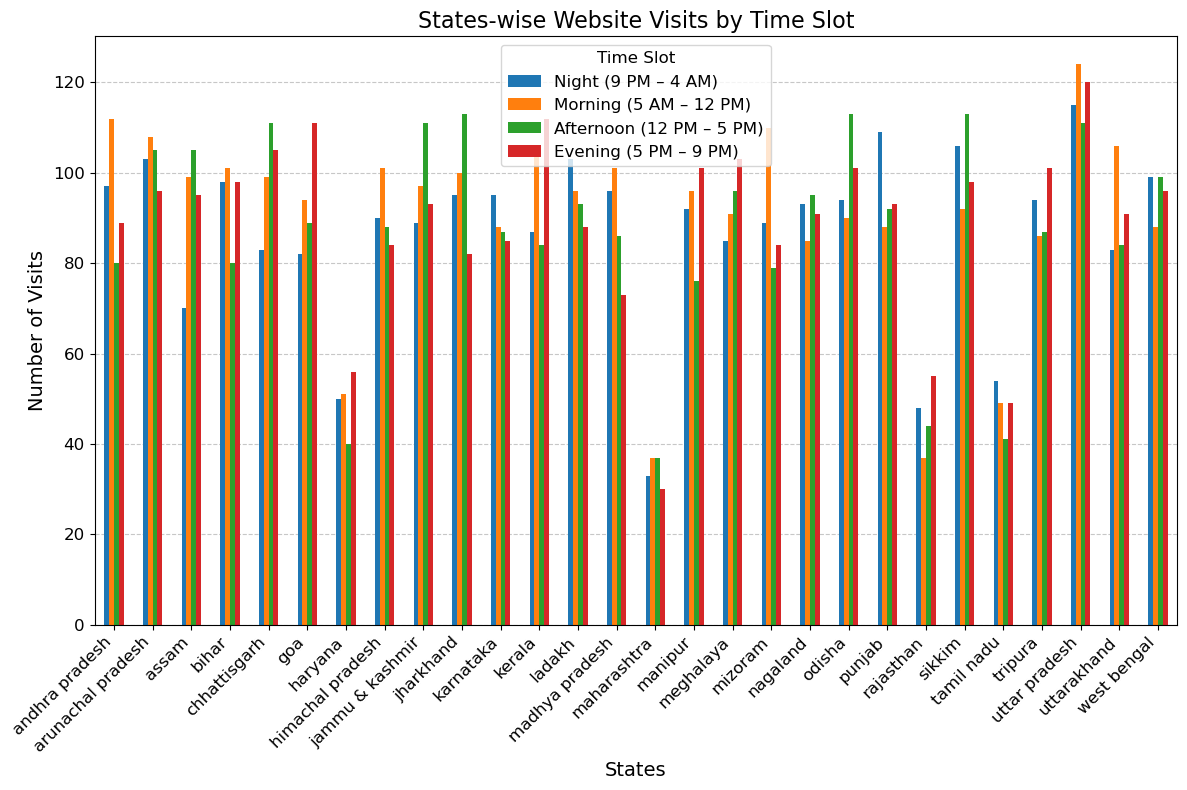

In [115]:
import matplotlib.pyplot as plt

ax = pivot_bar.plot(
    kind='bar',
    figsize=(12, 8)
)

plt.title('States-wise Website Visits by Time Slot', fontsize=16)
plt.xlabel('States', fontsize=14)
plt.ylabel('Number of Visits', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Grid lines behind bars
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Custom legend text
handles, labels = ax.get_legend_handles_labels()
custom_labels = [legend_labels[label] for label in labels]

ax.legend(
    handles,
    custom_labels,
    title='Time Slot',
    fontsize=12,
    title_fontsize=12
)

plt.tight_layout()
plt.show()


#### b) Age category visiting at which time slots? 

In [118]:
import pandas as pd

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 25, 35, 45, 60, 100],
    labels=['<18', '18-25', '26-35', '36-45', '46-60', '60+']
)


In [120]:
age_time = (
    df.groupby(['age_group', 'time_slot'], observed=True)
      .size()
      .reset_index(name='visits')
)


In [122]:
pivot_age_time = age_time.pivot(
    index='age_group',
    columns='time_slot',
    values='visits'
).fillna(0)


In [124]:
import pandas as pd

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 25, 35, 45, 60, 100],
    labels=['<18', '18-25', '26-35', '36-45', '46-60', '60+']
)


In [126]:
age_time = (
    df.groupby(['age_group', 'time_slot'], observed=True)
      .size()
      .reset_index(name='visits')
)


In [128]:
pivot_age_time = age_time.pivot(
    index='age_group',
    columns='time_slot',
    values='visits'
).fillna(0)


In [130]:
pivot_age_time.head()


time_slot,Night,Morning,Afternoon,Evening
age_group,,,,
<18,512,531,533,531
18-25,417,450,413,453
26-35,595,612,595,585
36-45,609,629,597,624
46-60,299,310,301,287


<Figure size 1000x600 with 0 Axes>

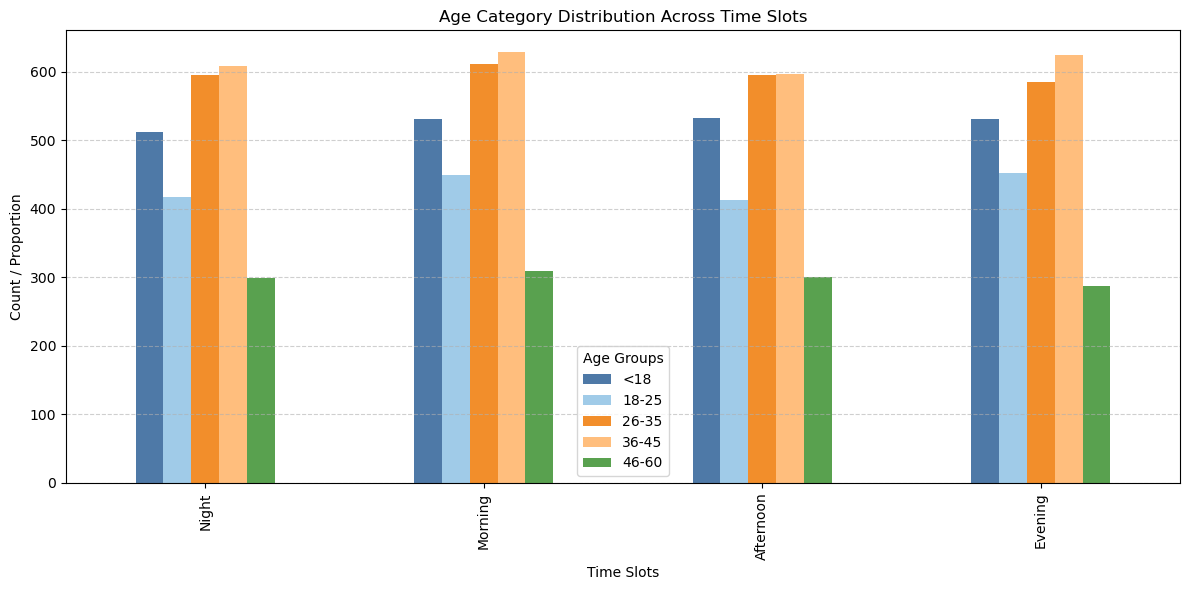

In [132]:
import matplotlib.pyplot as plt

# Define a professional color palette (muted tones)
colors = ["#4E79A7", "#A0CBE8", "#F28E2B", "#FFBE7D", 
          "#59A14F", "#8CD17D", "#B6992D", "#499894"]

plt.figure(figsize=(10, 6))

# Plot as grouped bar chart with custom colors
pivot_age_time.T.plot(
    kind='bar',
    figsize=(12, 6),
    color=colors
)

plt.title("Age Category Distribution Across Time Slots")
plt.xlabel("Time Slots")
plt.ylabel("Count / Proportion")

# Add subtle grid lines behind bars
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.legend(title="Age Groups")
plt.tight_layout()
plt.show()

#### C) Average time spent (minutes) – City & State wise

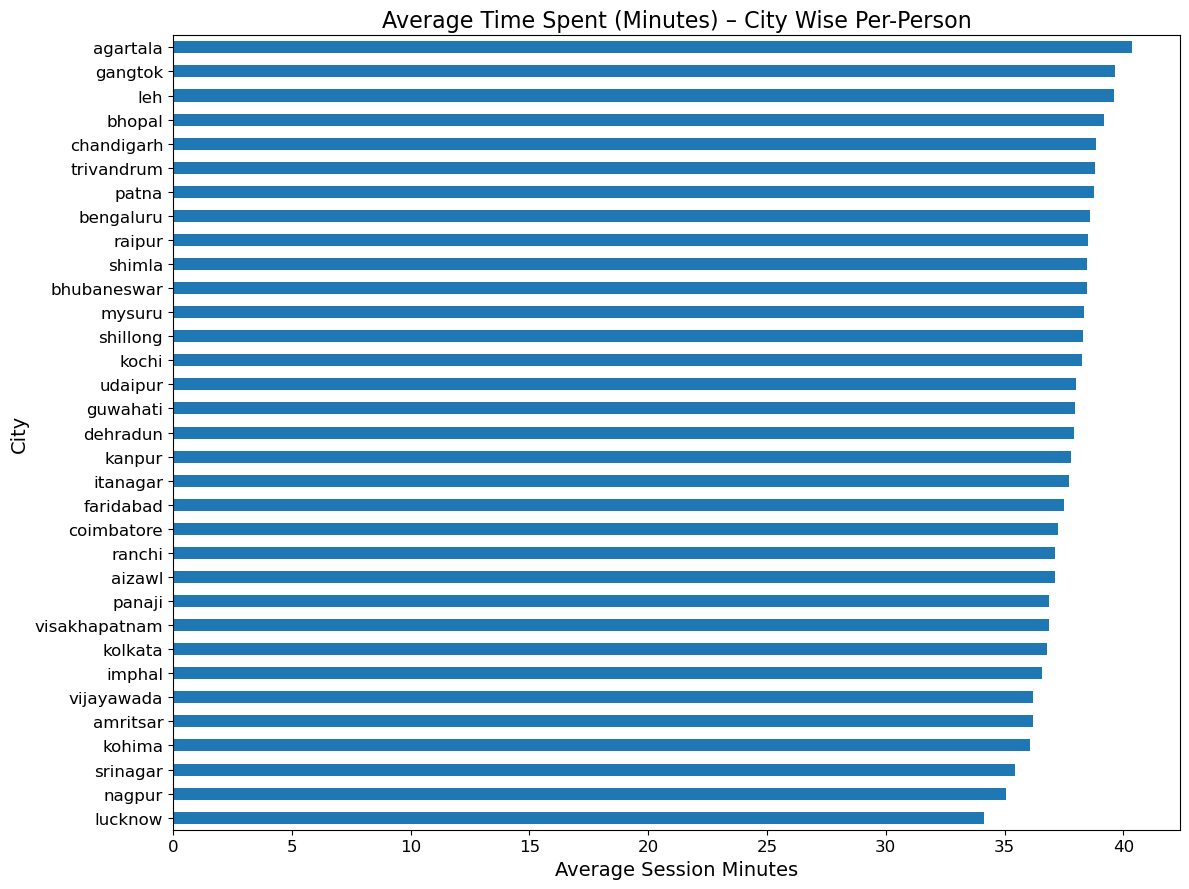

In [135]:
import matplotlib.pyplot as plt

df['session_minutes'] = df['session_duration_sec'] / 60

city_avg = df.groupby('city')['session_minutes'].mean().sort_values()

# Horizontal bar chart with bigger size
city_avg.plot(kind='barh', figsize=(12,9))

plt.title("Average Time Spent (Minutes) – City Wise Per-Person", fontsize=16)
plt.xlabel("Average Session Minutes", fontsize=14)
plt.ylabel("City", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


#### d) Total Average Time on Website

In [138]:
df['session_minutes'].mean()

37.75999359168943

In [140]:
import matplotlib.pyplot as plt

festival_traffic = (
    df.groupby('festival')['purchase']
      .sum()
      .reset_index()
)


### Problem Statement 2: User Behavior's.

#### Importing Pandas and Matplotlib libraries

In [144]:
import pandas as pd
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)


#### Uploading Dataset

In [147]:
file_path = "Ecommerce_Website_Traffic_India_more_data.xlsx"
df = pd.read_excel(file_path)

df.head()
# Checking data set with df.head()

,date,time,user_id,traffic_source,device,city,state,session_duration_sec,pages_viewed,bounce,product_viewed,home_appliances,office_equipments,beauty_products,clothing,technical_devices,add_to_cart,purchase,order_value,age,gender,festival
0,2024-11-08 00:00:00,19:23:09,U100000,Organic Search,Tablet,Ranchi,Jharkhand,2152,16,0,1,0,0,48,25,51,1,0,0.0,41,Male,Diwali
1,2024-05-25 00:00:00,15:47:18,U100001,Referral,Mobile,Bhubaneswar,Odisha,3161,16,0,0,0,0,31,46,62,0,0,0.0,34,Female,Holi
2,2024-05-02 00:00:00,NaN,U100002,Organic Search,Tablet,Chennai,Tamil Nadu,2151,3,0,0,0,18,10,1,0,0,0,0.0,46,Female,Pongal
3,2024-10-09 00:00:00,12:39:18,U100003,Direct,Mobile,Kolkata,West Bengal,2941,2,0,1,0,0,7,1,0,0,0,0.0,32,Male,Pongal
4,2024-01-17 00:00:00,10:57:32,NaN,Paid Ads,Tablet,Trivandrum,Kerala,2648,1,1,0,0,0,46,78,56,0,0,0.0,18,Female,Navratri


#### Convert numeric columns safely.

In [149]:
    
numeric_cols = [
    'purchase', 'pages_viewed', 'session_duration_sec',
    'order_value', 'add_to_cart'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values
df[numeric_cols] = df[numeric_cols].fillna(0)

df.isnull().sum()


date                    0
time                    1
user_id                 1
traffic_source          0
device                  0
city                    0
state                   0
session_duration_sec    0
pages_viewed            0
bounce                  0
product_viewed          0
home_appliances         0
office_equipments       0
beauty_products         0
clothing                0
technical_devices       0
add_to_cart             0
purchase                0
order_value             0
age                     0
gender                  0
festival                0
dtype: int64

#### a) Traffice Source Vs Total Purchases. 

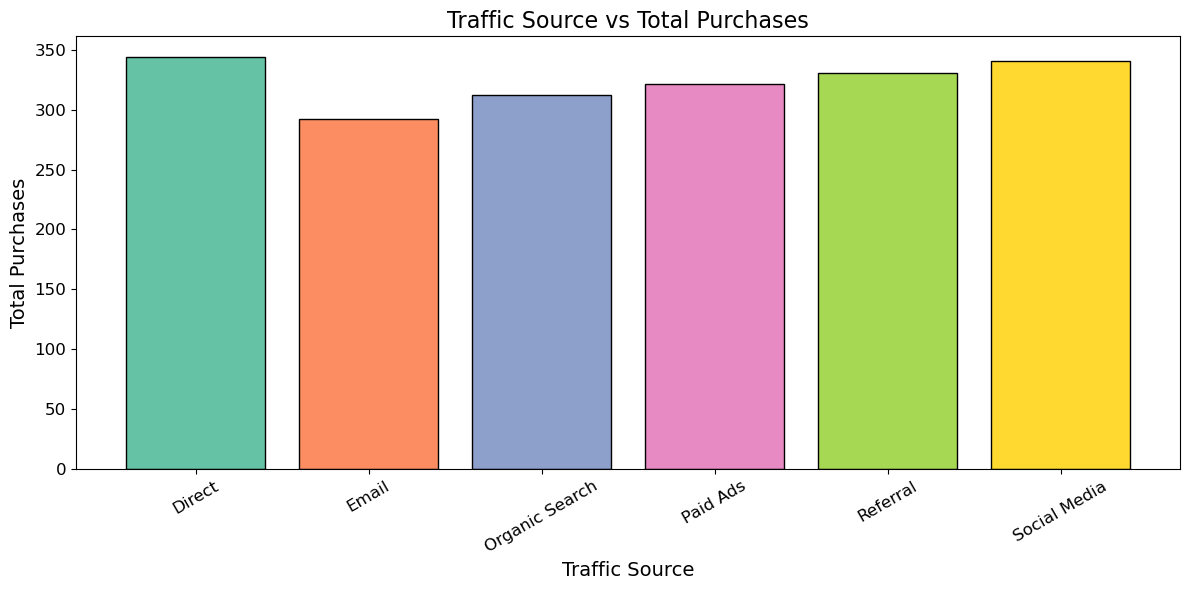

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

traffic_purchase = df.groupby('traffic_source')['purchase'].sum()

plt.figure(figsize=(12, 6))

# Use a clean professional palette
colors = sns.color_palette("Set2", len(traffic_purchase))

plt.bar(
    traffic_purchase.index,
    traffic_purchase.values,
    color=colors,
    edgecolor='black'
)

plt.title("Traffic Source vs Total Purchases", fontsize=16)
plt.xlabel("Traffic Source", fontsize=14)
plt.ylabel("Total Purchases", fontsize=14)
plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

#### b) Add To Cart Vs Purchases.

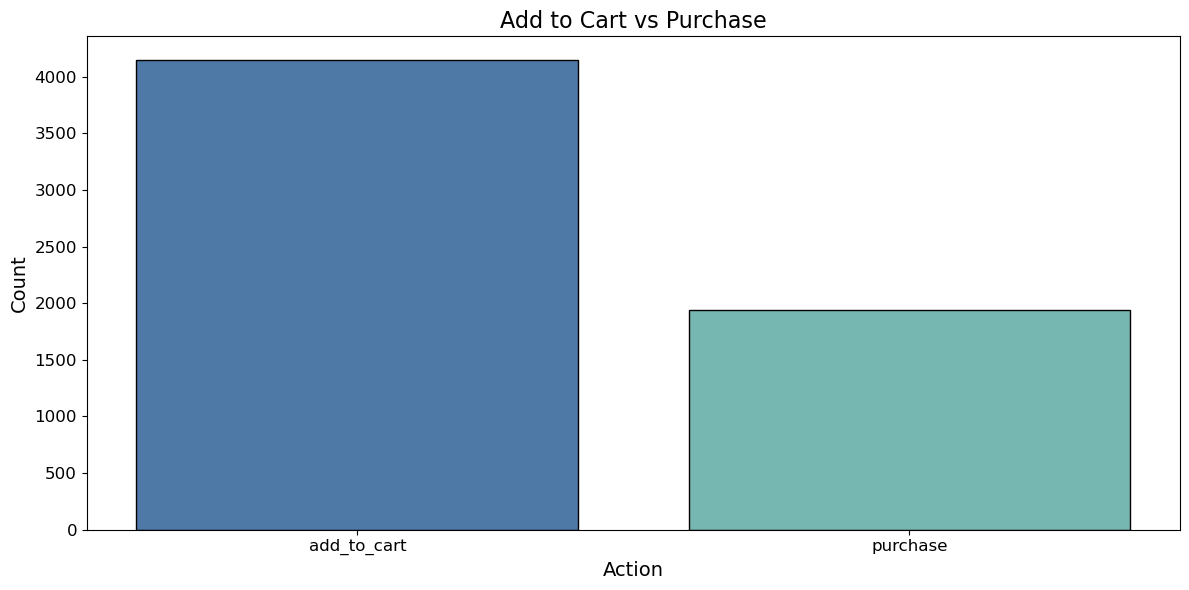

In [156]:
import matplotlib.pyplot as plt

conversion_data = df[['add_to_cart', 'purchase']].sum()

plt.figure(figsize=(12, 6))

plt.bar(
    conversion_data.index,
    conversion_data.values,
    color=['#4E79A7', '#76B7B2'],  # professional light colors
    edgecolor='black'
)

plt.title("Add to Cart vs Purchase", fontsize=16)
plt.xlabel("Action", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

#### c) Number Of People Visiting Devices Medium 

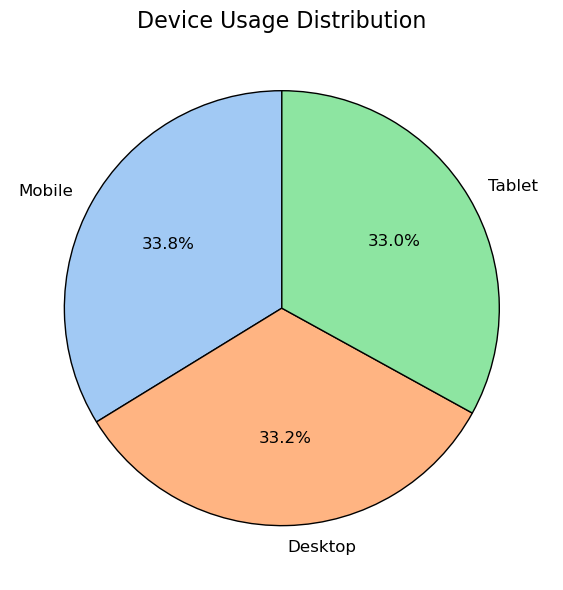

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

device_usage = df['device'].value_counts()

plt.figure(figsize=(12, 6))

# Use professional-lite pastel colors
colors = sns.color_palette("pastel", len(device_usage))

plt.pie(
    device_usage.values,
    labels=device_usage.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 12}
)

plt.title("Device Usage Distribution", fontsize=16)
plt.tight_layout()
plt.show()


#### d) Top 10 States By Purchases.

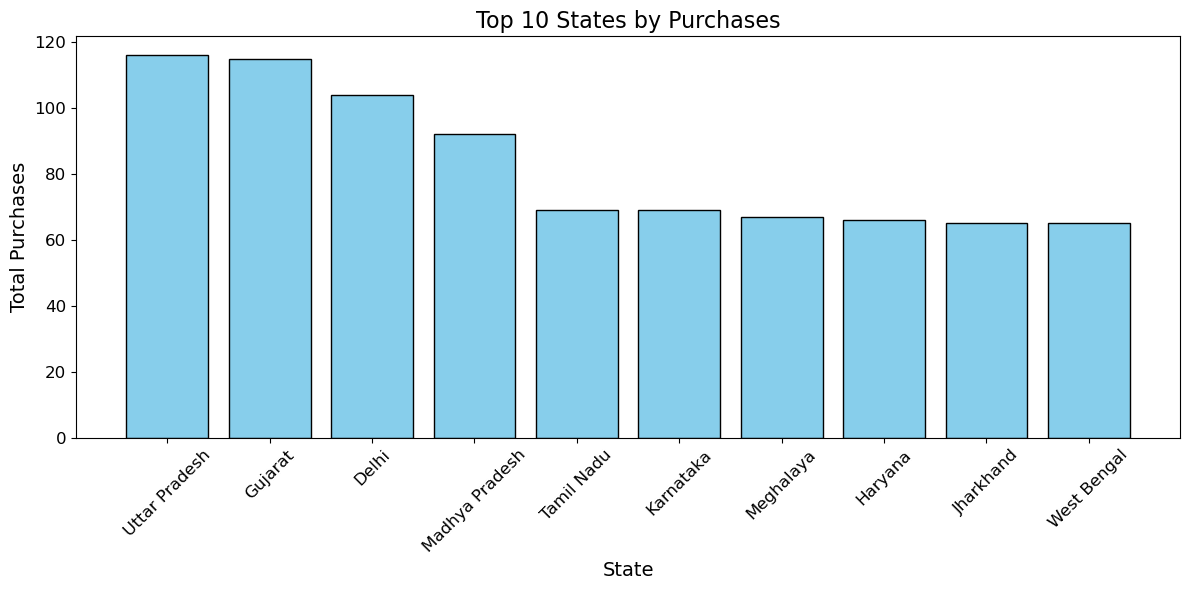

In [162]:
import matplotlib.pyplot as plt

state_purchase = (
    df.groupby('state')['purchase']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))  # Increased size

plt.bar(state_purchase.index, state_purchase.values, color='skyblue', edgecolor='black')  # optional color styling
plt.title("Top 10 States by Purchases", fontsize=16)
plt.xlabel("State", fontsize=14)
plt.ylabel("Total Purchases", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


### Problem Statement 3: Conversion Trends.

#### a) Festival Vs Purchase Trend

<module 'matplotlib.pyplot' from 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

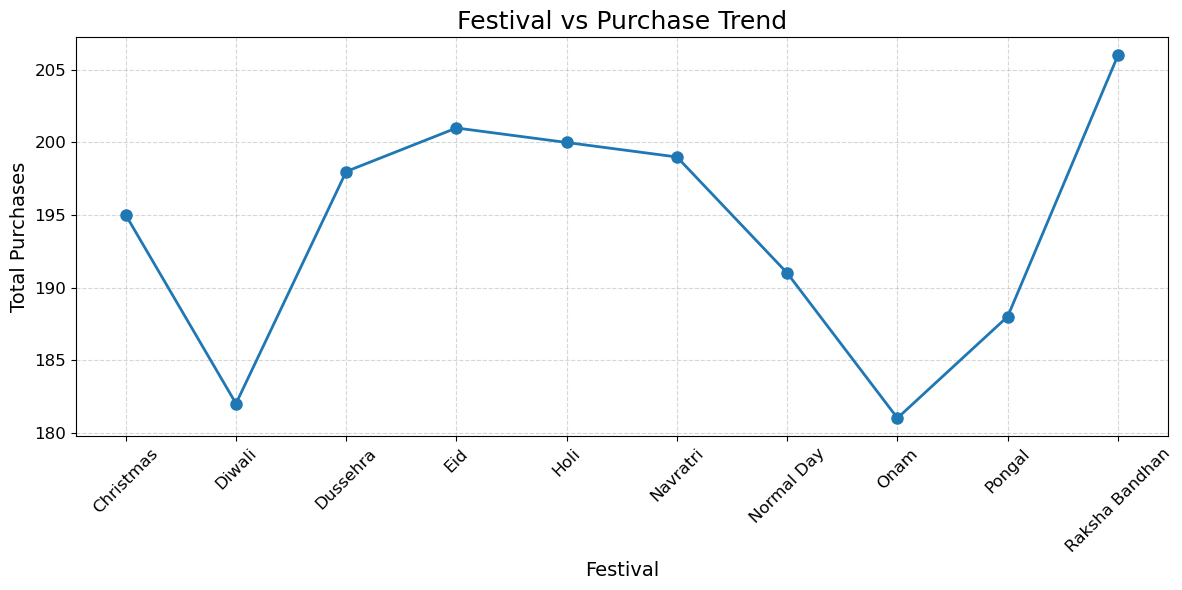

In [166]:
import matplotlib.pyplot as plt

festival_purchase = df.groupby('festival')['purchase'].sum()

plt.figure(figsize=(12, 6))  # Bigger figure

plt.plot(
    festival_purchase.index,
    festival_purchase.values,
    marker='o',
    linewidth=2,      # slightly thicker line for clarity
    markersize=8      # larger marker size
)

plt.title("Festival vs Purchase Trend", fontsize=18)
plt.xlabel("Festival", fontsize=14)
plt.ylabel("Total Purchases", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt


#### Import Libraries

In [169]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


#### Load Dataset

In [172]:
df = pd.read_excel("Ecommerce_Website_Traffic_India_more_data.xlsx")
df.head()


,date,time,user_id,traffic_source,device,city,state,session_duration_sec,pages_viewed,bounce,product_viewed,home_appliances,office_equipments,beauty_products,clothing,technical_devices,add_to_cart,purchase,order_value,age,gender,festival
0,2024-11-08 00:00:00,19:23:09,U100000,Organic Search,Tablet,Ranchi,Jharkhand,2152,16,0,1,0,0,48,25,51,1,0,0.0,41,Male,Diwali
1,2024-05-25 00:00:00,15:47:18,U100001,Referral,Mobile,Bhubaneswar,Odisha,3161,16,0,0,0,0,31,46,62,0,0,0.0,34,Female,Holi
2,2024-05-02 00:00:00,NaN,U100002,Organic Search,Tablet,Chennai,Tamil Nadu,2151,3,0,0,0,18,10,1,0,0,0,0.0,46,Female,Pongal
3,2024-10-09 00:00:00,12:39:18,U100003,Direct,Mobile,Kolkata,West Bengal,2941,2,0,1,0,0,7,1,0,0,0,0.0,32,Male,Pongal
4,2024-01-17 00:00:00,10:57:32,NaN,Paid Ads,Tablet,Trivandrum,Kerala,2648,1,1,0,0,0,46,78,56,0,0,0.0,18,Female,Navratri


#### Data Cleaning

In [174]:
numeric_cols = [
    'session_duration_sec','pages_viewed','home_appliances',
    'office_equipments','beauty_products','clothing',
    'technical_devices','add_to_cart','purchase','order_value','age'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['month'] = df['date'].dt.month_name()


#### b) State vs Product Purchase (Heatmap)

In [178]:
print(df.columns.tolist())


['date', 'time', 'user_id', 'traffic_source', 'device', 'city', 'state', 'session_duration_sec', 'pages_viewed', 'bounce', 'product_viewed', 'home_appliances', 'office_equipments', 'beauty_products', 'clothing', 'technical_devices', 'add_to_cart', 'purchase', 'order_value', 'age', 'gender', 'festival', 'month']


In [180]:
products = [
    'home_appliances',
    'office_equipments',
    'beauty_products',
    'clothing',
    'technical_devices'
]

state_product = df.groupby('state')[products].sum()


In [182]:
state_product_norm = state_product.div(
    state_product.sum(axis=1),
    axis=0
)


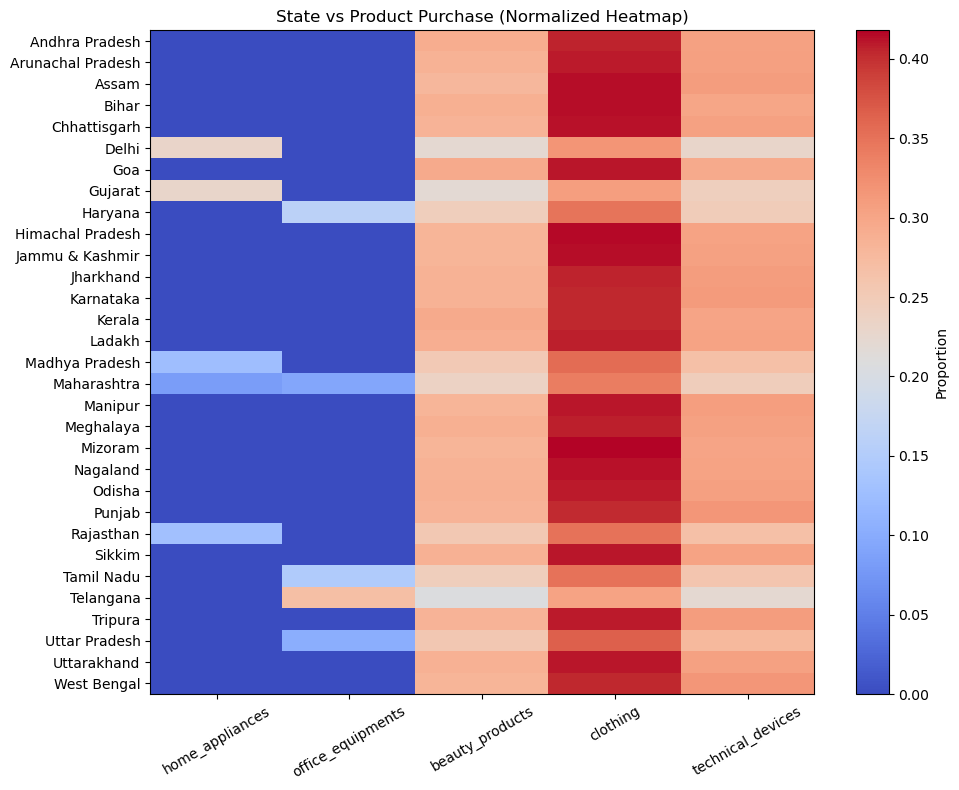

In [184]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(
    state_product_norm.values,
    aspect='auto',
    cmap='coolwarm'   #coolwarm color palette
)

plt.xticks(
    range(len(state_product_norm.columns)),
    state_product_norm.columns,
    rotation=30
)

plt.yticks(
    range(len(state_product_norm.index)),
    state_product_norm.index
)

plt.colorbar(label="Proportion")
plt.title("State vs Product Purchase (Normalized Heatmap)")
plt.tight_layout()
plt.show()


#### c) Monthly Highest & Lowest Sales (Bar Chart)

In [187]:
product_order = [
    'home_appliances',
    'office_equipments',
    'beauty_products',
    'clothing',
    'technical_devices'
]


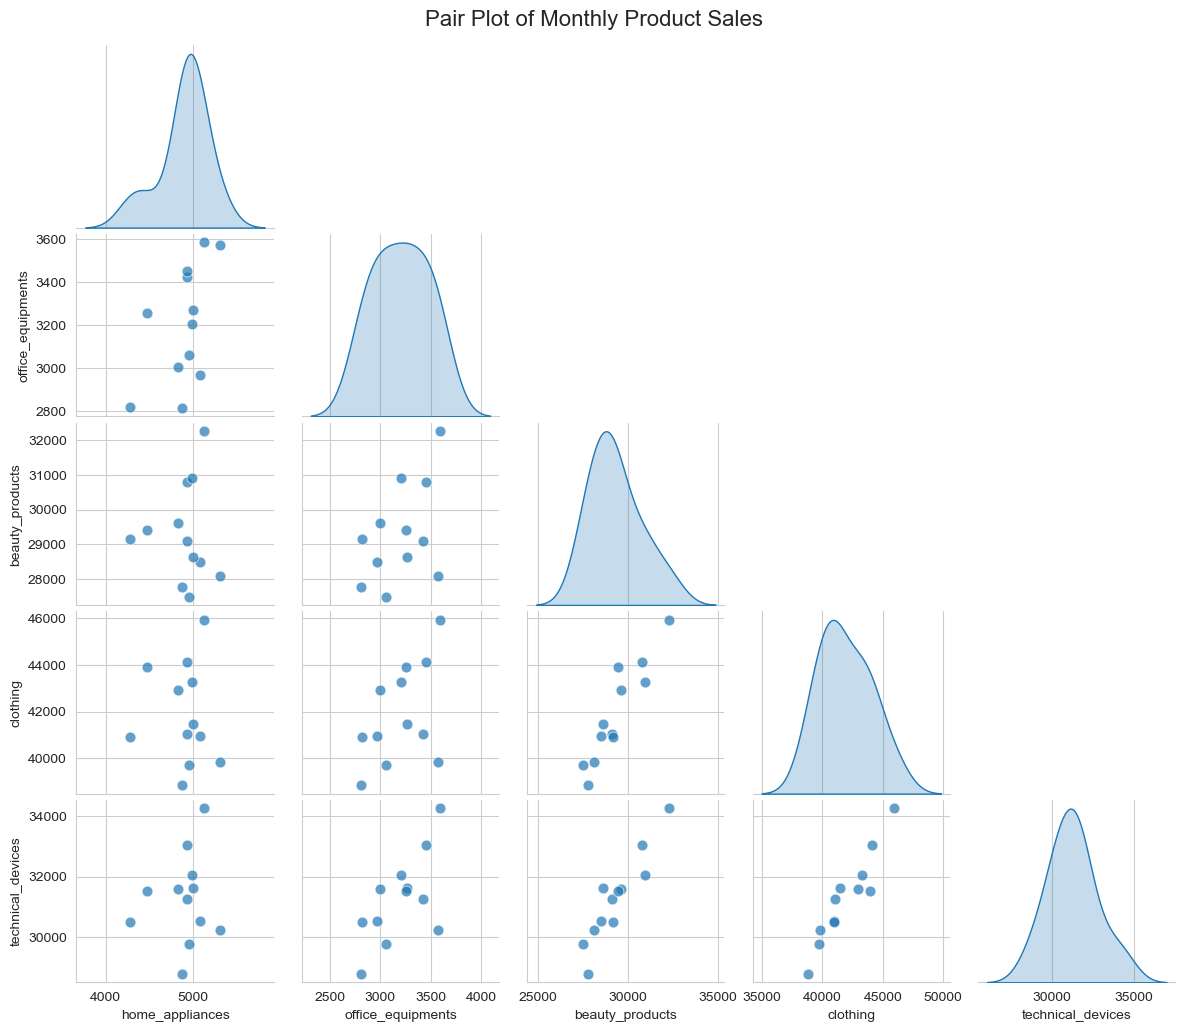

In [189]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

monthly_sales = df.groupby('month')[product_order].sum().reset_index()

pair = sns.pairplot(
    monthly_sales[product_order],
    diag_kind='kde',
    corner=True,
    plot_kws={
        'alpha': 0.7,
        's': 60
    },
    diag_kws={
        'fill': True
    }
)

pair.fig.set_size_inches(12, 10)
pair.fig.suptitle(
    "Pair Plot of Monthly Product Sales",
    y=1.02,
    fontsize=16
)

plt.show()


C:\Users\Hitesh\AppData\Local\Temp\ipykernel_33420\1459275208.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby('month')[products].sum()


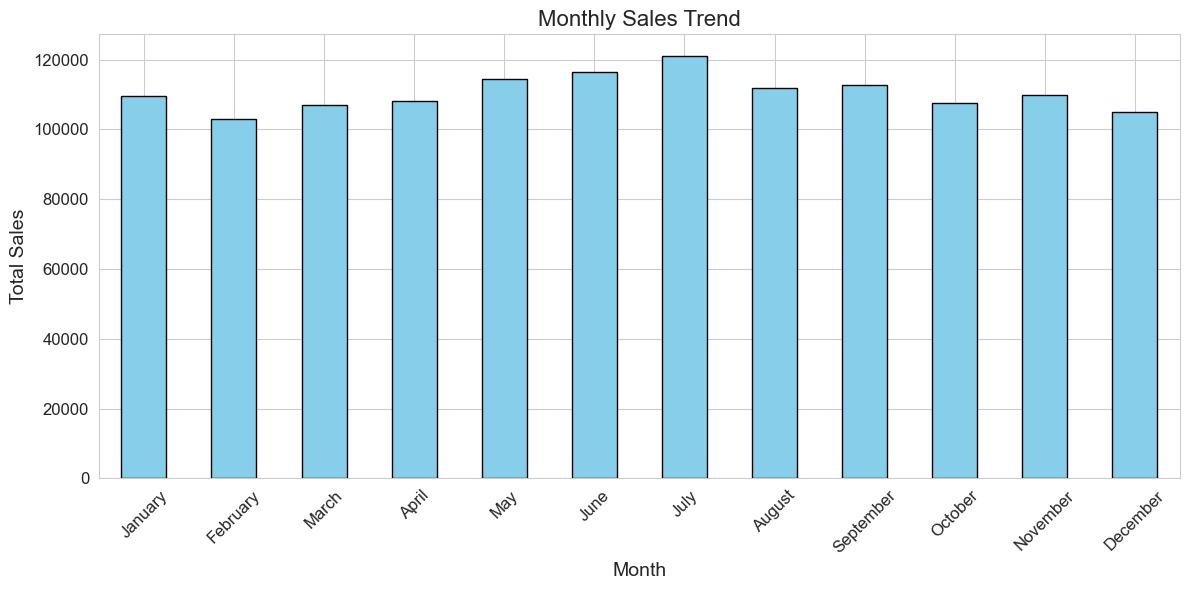

In [191]:
import matplotlib.pyplot as plt
import pandas as pd

# Define proper month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert 'month' column to categorical type with this order
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# Group by month in correct order
monthly_sales = df.groupby('month')[products].sum()

plt.figure(figsize=(12,6))  # Bigger figure for clarity
monthly_sales.sum(axis=1).plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel("Month", fontsize=14)
plt.ylabel("Total Sales", fontsize=14)
plt.title("Monthly Sales Trend", fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


#### d) Total Number of Sold Products

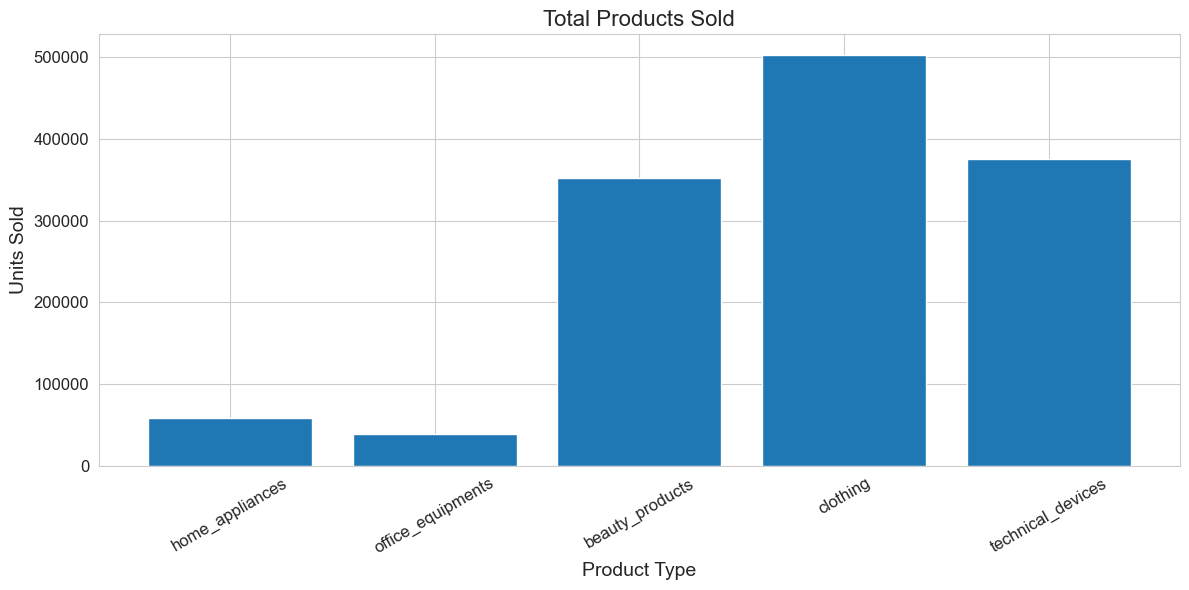

In [194]:
import matplotlib.pyplot as plt

total_sold = df[products].sum()

plt.figure(figsize=(12, 6))  # Increased size

plt.bar(total_sold.index, total_sold.values)
plt.xlabel("Product Type", fontsize=14)
plt.ylabel("Units Sold", fontsize=14)
plt.title("Total Products Sold", fontsize=16)
plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


#### d) User Purchasing Capacity (Boxplot – State Wise)

C:\Users\Hitesh\AppData\Local\Temp\ipykernel_33420\2109751855.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


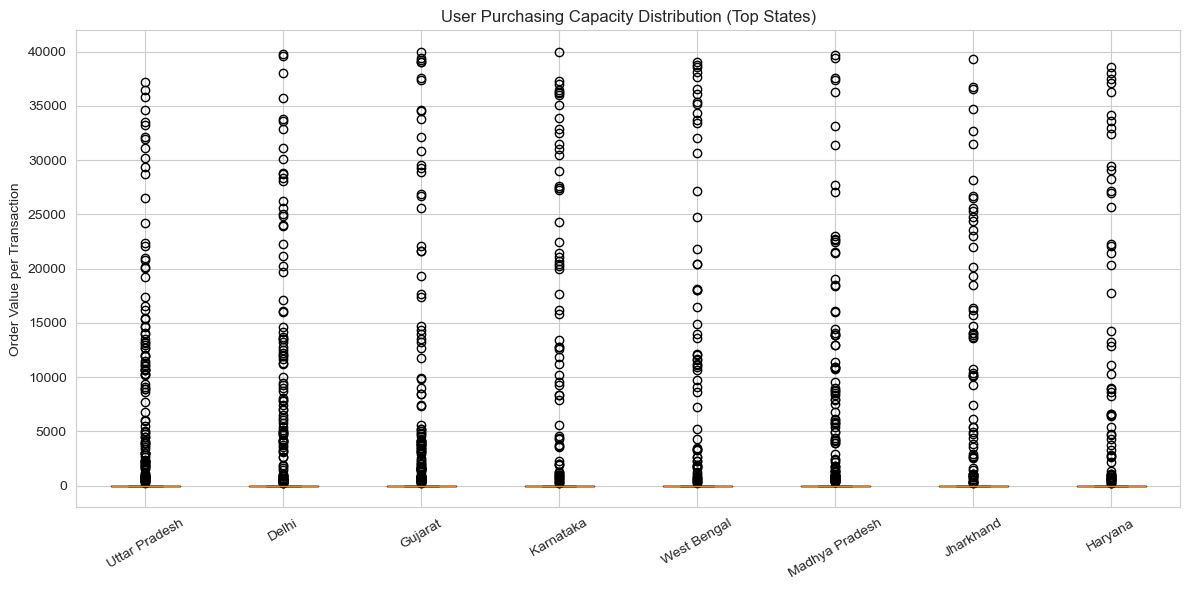

In [197]:
# Select top 8 states by total order value
top_states = (
    df.groupby('state')['order_value']
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

df_top = df[df['state'].isin(top_states)]

plt.figure(figsize=(12,6))
plt.boxplot(
    [df_top[df_top['state'] == s]['order_value'] for s in top_states],
    labels=top_states,
    showfliers=True
)

plt.xticks(rotation=30)
plt.ylabel("Order Value per Transaction")
plt.title("User Purchasing Capacity Distribution (Top States)")
plt.tight_layout()
plt.show()


#### e) Conversion Trends (Line Plot)

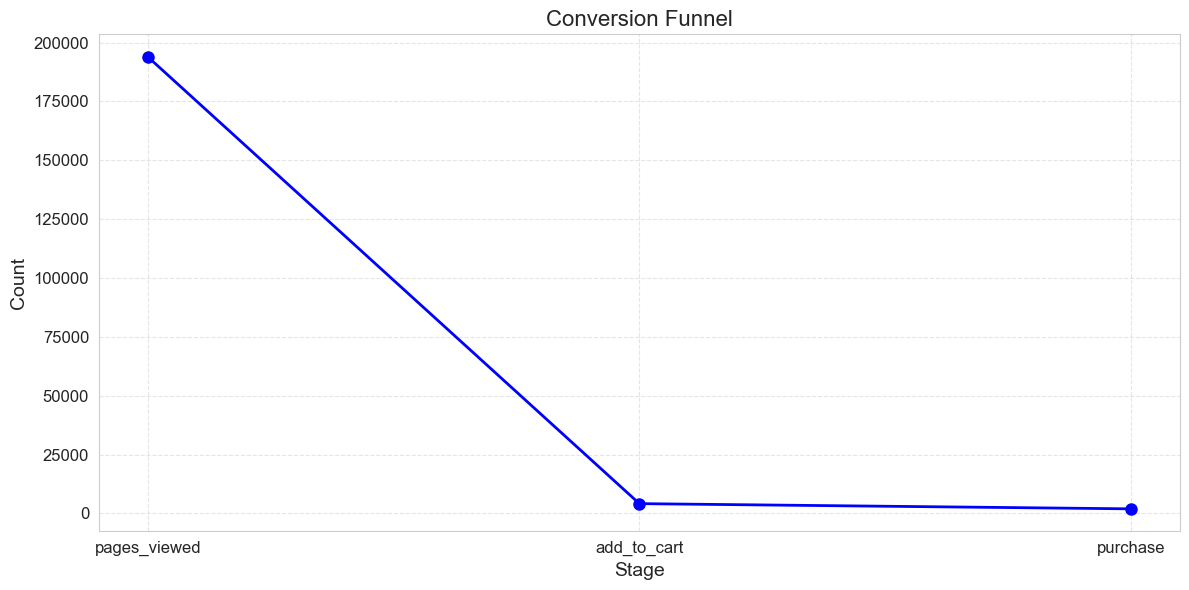

In [200]:
import matplotlib.pyplot as plt

conversion = df[['pages_viewed','add_to_cart','purchase']].sum()

plt.figure(figsize=(12, 6))  # Bigger figure

plt.plot(
    conversion.index,
    conversion.values,
    marker='o',
    linewidth=2,
    markersize=8,
    color='blue'
)
plt.xlabel("Stage", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Conversion Funnel", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


#### f) Festival with Highest & Lowest Sales

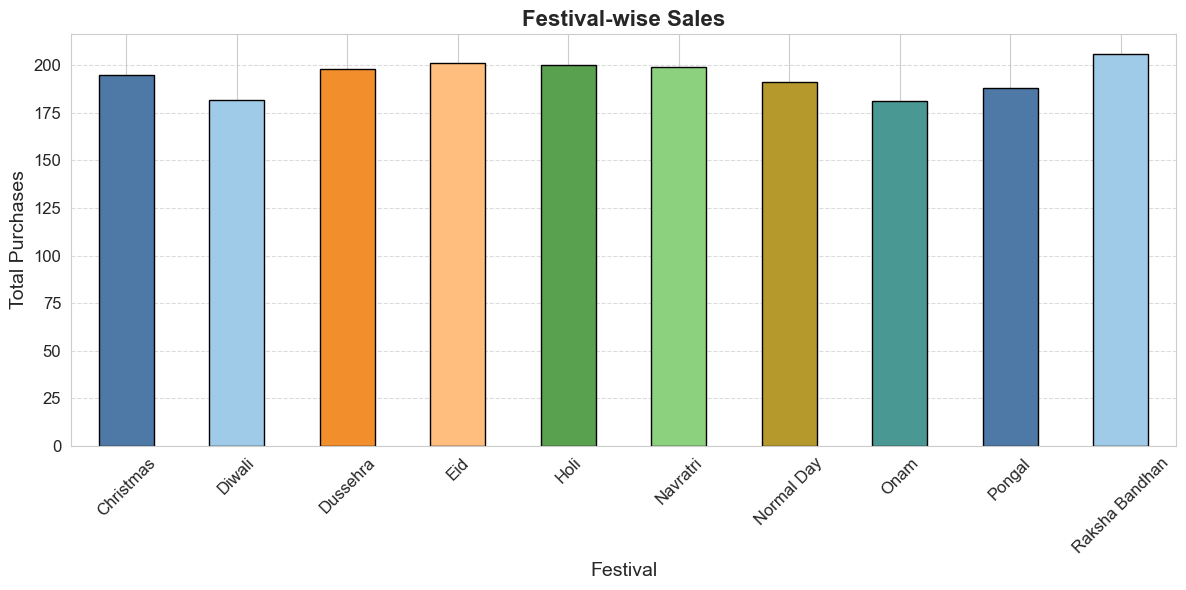

In [203]:
import matplotlib.pyplot as plt

# Group sales by festival
festival_sales = df.groupby('festival')['purchase'].sum()

plt.figure(figsize=(12, 6))  # Larger figure for clarity

# Professional color palette (muted, business-style)
colors = ['#4E79A7', '#A0CBE8', '#F28E2B', '#FFBE7D',
          '#59A14F', '#8CD17D', '#B6992D', '#499894']

# Plot bar chart
festival_sales.plot(
    kind='bar',
    color=colors[:len(festival_sales)],  # assign one color per bar
    edgecolor='black'
)

# Labels and title
plt.xlabel("Festival", fontsize=14)
plt.ylabel("Total Purchases", fontsize=14)
plt.title("Festival-wise Sales", fontsize=16, fontweight='bold')

# Axis formatting
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### h) Age Group vs Product Search (2D Histogram)

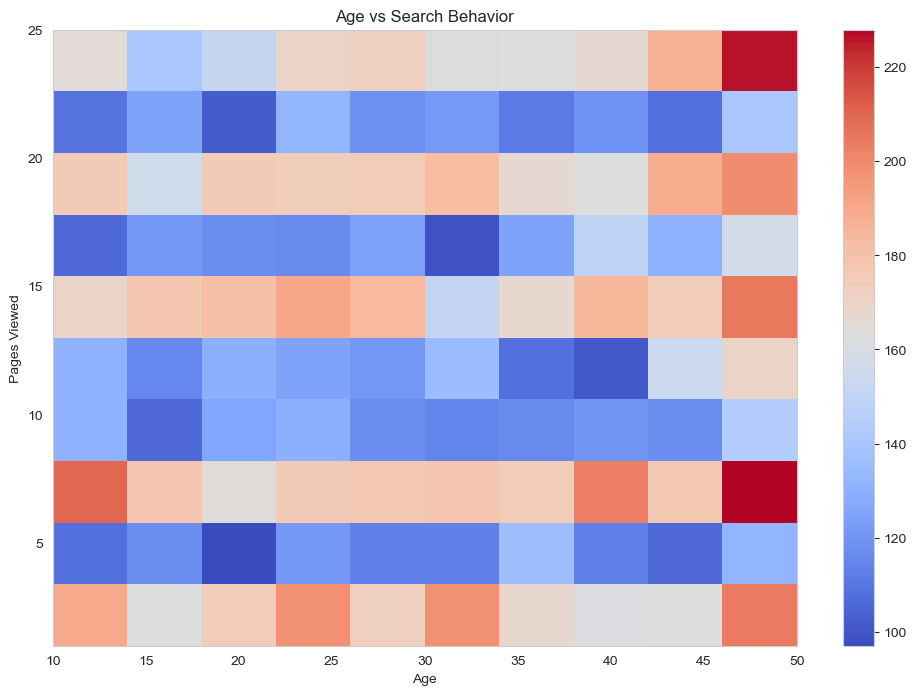

In [206]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))  # Increase figure size

plt.hist2d(
    df['age'],
    df['pages_viewed'],
    cmap='coolwarm'   #color changed here
)

plt.colorbar()
plt.xlabel("Age")
plt.ylabel("Pages Viewed")
plt.title("Age vs Search Behavior")
plt.show()


#### i) Gender-wise Traffic Count & Percentage

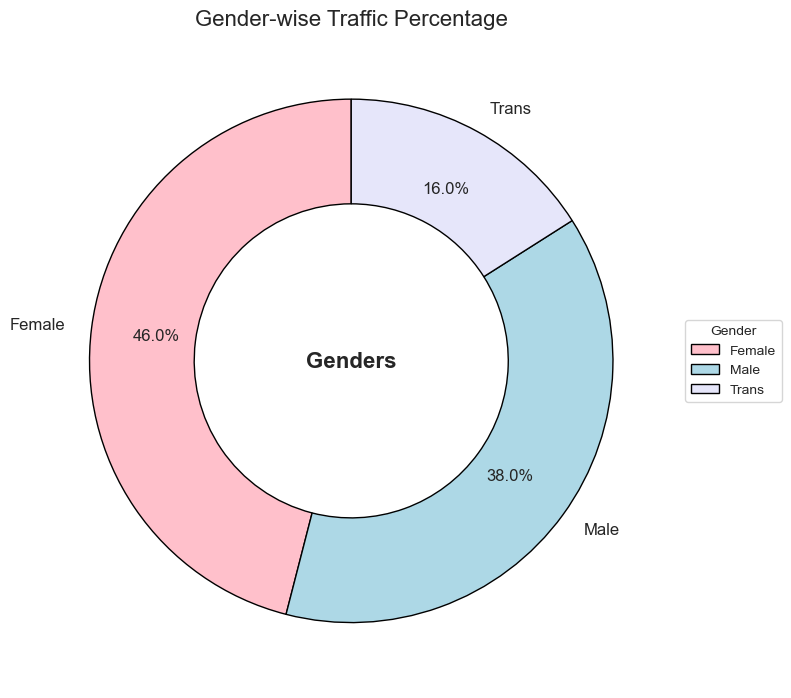

In [209]:
import matplotlib.pyplot as plt

# Count gender values
gender_count = df['gender'].value_counts()

plt.figure(figsize=(8, 8))

# Define custom colors
color_map = {
    'Female': '#FFC0CB',
    'Male': '#ADD8E6',
    'Trans': '#E6E6FA'
}

colors = [color_map[gender] for gender in gender_count.index]

# Create donut chart
wedges, texts, autotexts = plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct='%1.1f%%',
    pctdistance=0.75,        # moves % labels inside
    startangle=90,
    colors=colors,
    wedgeprops={
        'edgecolor': 'black',
        'width': 0.4
    },
    textprops={'fontsize': 12}
)

# Center text
plt.text(
    0, 0, "Genders",
    ha='center',
    va='center',
    fontsize=16,
    fontweight='bold'
)

plt.title("Gender-wise Traffic Percentage", fontsize=16)

# Legend
plt.legend(
    wedges,
    gender_count.index,
    title="Gender",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.tight_layout()
plt.show()


#### j) Gender Percentage by State (Heatmap)

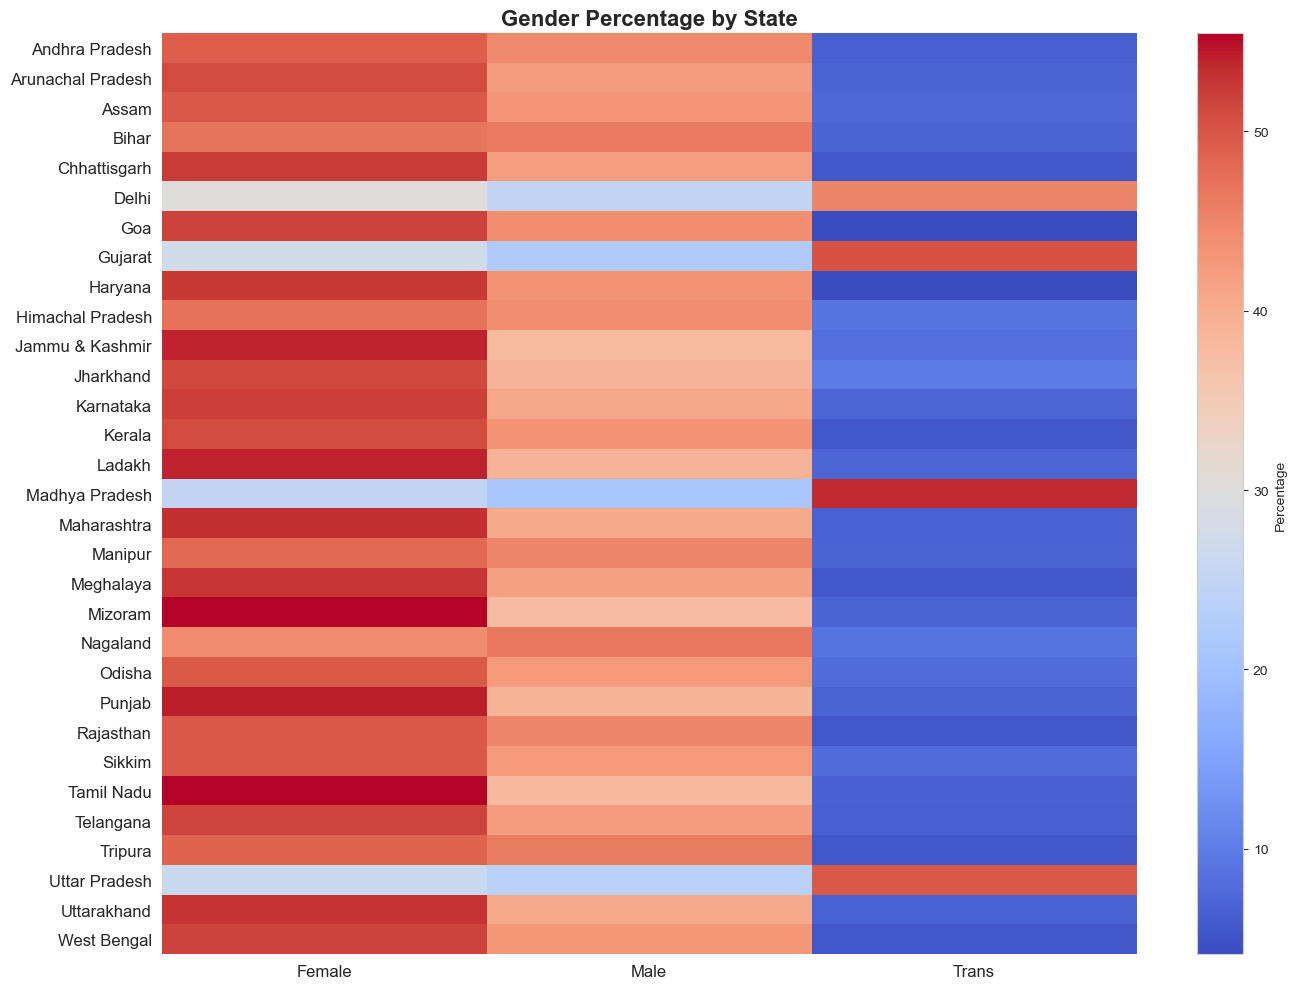

In [212]:
import matplotlib.pyplot as plt
import pandas as pd

gender_state = pd.crosstab(df['state'], df['gender'], normalize='index') * 100

plt.figure(figsize=(14, 10))

im = plt.imshow(
    gender_state.values,
    cmap='coolwarm',
    aspect='auto'
)

plt.xticks(
    range(len(gender_state.columns)),
    gender_state.columns,
    fontsize=12
)

plt.yticks(
    range(len(gender_state.index)),
    gender_state.index,
    fontsize=12
)

plt.colorbar(im, label="Percentage")

plt.title(
    "Gender Percentage by State",
    fontsize=16,
    fontweight='bold'
)

# Remove gridlines & borders
plt.grid(False)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()
